In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import root

In [2]:
#Cargar datos
LABELS = ["Alt_Si3N4", "Anc_Si3N4", "lambda", "n_eff", "A_eff"]

def load_and_normalize(fname):
    with h5py.File(fname, "r") as f:
        A = f["/A"][...]
    axis5 = next((ax for ax, s in enumerate(A.shape) if s == 5), None)
    if axis5 is None:
        raise ValueError(f"No encontré eje de tamaño 5 en {fname}")
    if axis5 != A.ndim - 1:
        A = np.moveaxis(A, axis5, -1)
    return A

In [3]:
archivos = [
    "Datos_reto/Datos9.h5",
    "Datos_reto/Datos11.h5"
]
datasets = [load_and_normalize(fname) for fname in archivos]

def check_borders(d1, d2):
    alt1_end = np.round(d1[-1,0,0,0],6)
    alt2_start = np.round(d2[0,0,0,0],6)
    anc1_end = np.round(d1[0,-1,0,1],6)
    anc2_start = np.round(d2[0,0,0,1],6)
    print(f"Check Alt: {alt1_end} vs {alt2_start}, Check Anc: {anc1_end} vs {anc2_start}")
    if not np.isclose(alt1_end, alt2_start) and not np.isclose(anc1_end, anc2_start):
        print("⚠️ Advertencia: los bordes no coinciden perfectamente")

for i in range(len(datasets)-1):
    check_borders(datasets[i], datasets[i+1])

DatosU = np.concatenate(datasets, axis=0)

with h5py.File("Datos_reto/DatosU.h5", "w") as f_out:
    f_out.create_dataset("A", data=DatosU)

print("✅ Dataset unificado guardado en DatosU.h5, shape:", DatosU.shape)

def to_dataframe(arr):
    nA, nB, nC, _ = arr.shape
    rows = []
    for ii in range(nA):
        for jj in range(nB):
            for kk in range(nC):
                rec = {"i": ii+1, "j": jj+1, "k": kk+1}
                for p, name in enumerate(LABELS):
                    rec[name] = arr[ii, jj, kk, p]
                rows.append(rec)
    return pd.DataFrame(rows, columns=["i","j","k"]+LABELS)

df = to_dataframe(DatosU)
df["lambda_nm"] = df["lambda"] * 1000 
print(df)

df.to_csv('Datos_reto/DatosU.csv', index=False)

Check Alt: 0.4 vs 0.4, Check Anc: 2.0 vs 0.5
✅ Dataset unificado guardado en DatosU.h5, shape: (100, 10, 10, 5)
        i   j   k  Alt_Si3N4  Anc_Si3N4  lambda     n_eff         A_eff  \
0       1   1   1   0.400000        0.5   1.035  1.594476  3.233126e-13   
1       1   1   2   0.466667        0.5   1.035  1.627080  3.328044e-13   
2       1   1   3   0.533333        0.5   1.035  1.652778  3.492393e-13   
3       1   1   4   0.600000        0.5   1.035  1.672627  3.684361e-13   
4       1   1   5   0.666667        0.5   1.035  1.688365  3.893655e-13   
...   ...  ..  ..        ...        ...     ...       ...           ...   
9995  100  10   6   0.733333        2.0   1.035  1.920578  9.078877e-13   
9996  100  10   7   0.800000        2.0   1.035  1.930293  9.668587e-13   
9997  100  10   8   0.866667        2.0   1.035  1.938219  1.026122e-12   
9998  100  10   9   0.933333        2.0   1.035  1.944864  1.086505e-12   
9999  100  10  10   1.000000        2.0   1.035  1.950377  1.14

In [ ]:
c = 2.9979e8      #m/s

pg = 30

intersecciones = []

def neff(lam, p):
    return np.polyval(p, lam)               #el neff no debe tener unidades

def neff_p(lam, dp):
    return np.polyval(dp, lam)              #tiene unidades de 1/la unida que le entre en mi caso 1/um

def k(lam, p):
    return (2*np.pi/lam) * neff(lam, p)         #tiene unidaes de lo que le entre, en este caso de 1/um

def k_prime(lam, p, dp):
    return (1/c)*(neff(lam, p) - lam*(neff_p(lam, dp)))             #tiene unidades de s/m por que lo que esta en parentesis no tiene unidaes

def k_of_omega(om, p):
    lam_um = (2*np.pi*c / om) * 1e6
    neff = np.polyval(p, lam_um)
    return (2*np.pi/lam_um)*neff * 1e6

In [5]:
#intento con una geometria aleatoria hacer el grafico de ts = -ti

jpn = 2       #Ancho
kpn = 1       #Alto

df_p = df[(df['j']==jpn) & (df['k']==kpn)]

lam_p = df_p['lambda'].values
neff_vals = df_p['n_eff'].values

alto = df_p['Alt_Si3N4'].iloc[0]
ancho = df_p['Anc_Si3N4'].iloc[0]

print(f"Geometría seleccionada: j={jpn}, k={kpn}")
print(f"Altura = {alto:.4f} µm")
print(f"Ancho  = {ancho:.4f} µm")

Geometría seleccionada: j=2, k=1
Altura = 0.4000 µm
Ancho  = 0.6667 µm


In [6]:
def neffvlambda(df, grado=30):
    if len(df) <= grado:
        raise ValueError("No hay suficientes puntos para ajuste polinomial.")

    x = df["lambda"].values
    y = df["n_eff"].values

    coef = np.polyfit(x, y, grado)
    p = np.poly1d(coef)
    return p

C:\Users\david\AppData\Local\Temp\ipykernel_40988\3842076212.py:8: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, grado)
C:\Users\david\AppData\Local\Temp\ipykernel_40988\1374874918.py:55: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  if len(CS.collections)==0:
C:\Users\david\AppData\Local\Temp\ipykernel_40988\1374874918.py:57: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for col in CS.collections:


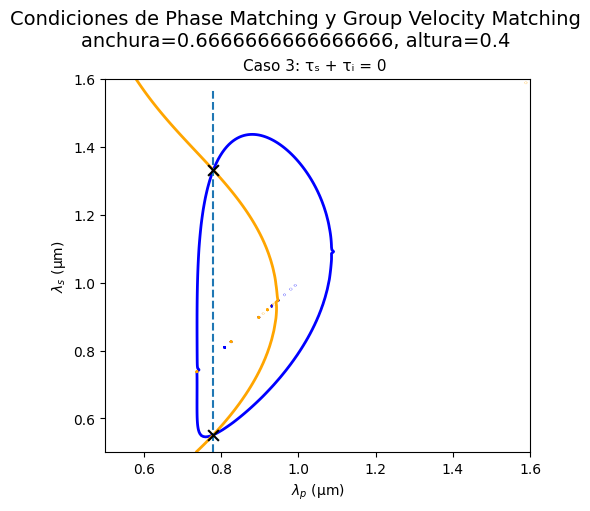

In [7]:
p = neffvlambda(df_p, pg)           #no tiene unidades
dp = np.polyder(p)                  #unidades de 1/um

Lamp = np.linspace(0.5, 1.6, 200)
Lams = np.linspace(0.5, 1.6, 200)
LAMP, LAMS = np.meshgrid(Lamp, Lams)

LAMI = 1/((2/LAMP)-(1/LAMS))

mask = np.isfinite(LAMI) & (LAMI > 0)

kp = k(LAMP, p)
ks = k(LAMS, p)
ki = np.full_like(ks, np.nan)
ki[mask] = k(LAMI[mask], p)

Dk = 2*kp - ks - ki

Taus = np.full_like(kp, np.nan)
Taui = np.full_like(kp, np.nan)

Taus[mask] = k_prime(LAMP[mask], p, dp) - k_prime(LAMS[mask], p, dp)            #s/m
Taui[mask] = k_prime(LAMP[mask], p, dp) - k_prime(LAMI[mask], p, dp)            #s/m

eps_dk  = 1e-4 * np.nanmedian(np.abs(Dk))   # o un percentil
eps_tau = 1e-6 * np.nanmedian(np.abs(Taus+Taui))

sTau = Taui + Taus          #s/m

mask1 = (np.abs(sTau) <= eps_tau) & (np.isfinite(sTau))
mask2 = (np.abs(Dk) <= eps_dk) & (np.isfinite(Dk))
mask3 = Taui*Taus < 0

maskf = mask1 & mask2 & mask3

def find_pm_gvm_intersections(lamp, lams, DK, TAU,
                              prox_pixels=1.0,        # vecindad para candidatos
                              tol_root=1e-12,         # tolerancia del solver
                              max_iter=50,            # iteraciones máximas
                              dedup_tol=1e-4):        # fusión de duplicados (µm)

    # 0) Interpoladores bilineales (permiten enmascarados NaN)
    f_DK  = RegularGridInterpolator((lams, lamp), DK,  bounds_error=False, fill_value=np.nan)
    f_TAU = RegularGridInterpolator((lams, lamp), TAU, bounds_error=False, fill_value=np.nan)

    # 1) Contornos (no se muestran)
    fig, ax = plt.subplots()
    CS1 = ax.contour(lamp, lams, DK,  levels=[0], colors='none')
    CS2 = ax.contour(lamp, lams, TAU, levels=[0], colors='none')
    plt.close(fig)

    # Extraer vértices de TODOS los path de cada contorno
    def collect_vertices(CS):
        verts = []
        if len(CS.collections)==0: 
            return np.empty((0,2))
        for col in CS.collections:
            for pth in col.get_paths():
                v = pth.vertices
                if v.size:
                    verts.append(v)
        return np.vstack(verts) if verts else np.empty((0,2))

    V1 = collect_vertices(CS1)  # puntos sobre Δk=0
    V2 = collect_vertices(CS2)  # puntos sobre TAU=0
    if V1.size==0 or V2.size==0:
        return np.empty((0,2))

    # 2) Candidatos por proximidad
    # Escala de pixel ~ paso máximo en ejes
    dλp = np.min(np.diff(lamp))
    dλs = np.min(np.diff(lams))
    pixel = max(dλp, dλs)
    tree = cKDTree(V2)
    idx_near = tree.query_ball_point(V1, r=prox_pixels*pixel)  # lista de listas

    seeds = []
    for i, lst in enumerate(idx_near):
        if not lst: 
            continue
        # semilla: punto de Δk=0 y su vecino más cercano de TAU=0
        p1 = V1[i]
        # escoge el más cercano para estabilizar la raíz
        d, j = tree.query(p1)
        p0 = 0.5*(p1 + V2[j])  # punto medio como mejor inicial
        seeds.append(p0)

    if not seeds:
        return np.empty((0,2))
    seeds = np.array(seeds)

    # 3) Refinamiento por raíz 2D
    def F(xy):
        λs, λp = xy[1], xy[0]  # cuidado: interpoladores reciben (λs, λp)
        val = np.array([f_DK((λs, λp)), f_TAU((λs, λp))])
        return val

    sols = []
    for p0 in seeds:
        sol = root(F, x0=p0, method='hybr', tol=tol_root, options={'maxfev': max_iter})
        if sol.success and np.all(np.isfinite(sol.x)):
            λp, λs = sol.x
            # descarta puntos fuera de dominio o donde alguna función no esté bien definida
            if (lamp.min()<=λp<=lamp.max()) and (lams.min()<=λs<=lams.max()):
                vals = F(sol.x)
                if np.all(np.isfinite(vals)) and np.linalg.norm(vals, ord=np.inf) < 5e-6:
                    sols.append([λp, λs])

    if not sols:
        return np.empty((0,2))
    sols = np.array(sols)

    # 4) Quitar duplicados cercanos
    keep = []
    used = np.zeros(len(sols), dtype=bool)
    for i in range(len(sols)):
        if used[i]: 
            continue
        close = np.linalg.norm(sols - sols[i], axis=1) < dedup_tol
        used[close] = True
        keep.append(sols[i])
    return np.array(keep)


pts = find_pm_gvm_intersections(Lamp, Lams, Dk, sTau)
if pts.size == 0:
    print("No hay intersecciones")
else:
    # filtra puntos casi en la diagonal λp≈λs (degenerados)
    delta = 1e-3  # µm
    mask = ~np.isclose(pts[:,0], pts[:,1], atol=delta)
    pts2 = pts[mask]

fig, axes = plt.subplots(1, 1, figsize=(5, 5), sharex=True, sharey=True,
                                     constrained_layout=True)
titles = ["Caso 3: τₛ + τᵢ = 0 "]
colors = ['orange']
taus_list = [Taui + Taus]

vmax = np.nanpercentile(np.abs(Dk), 99)
vmin = -vmax

# Contorno Δk = 0
plt.contour(LAMP, LAMS, Dk, levels=[0], colors='b', linewidths=2)
# Contorno τ = 0
plt.contour(LAMP, LAMS, taus_list[0], levels=[0], colors=colors[0], linewidths=2)
plt.vlines(pts2[:,0][0], 0.5, 1.57, linestyles='dashed')

axes.set_title(titles[0], fontsize=11)
axes.set_xlabel(r'$\lambda_p$ (µm)')
axes.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
axes.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

if len(pts2):
    plt.scatter(pts2[:,0], pts2[:,1], s=60, c='k', marker='x', zorder=5, label='PM ∩ GVM')

axes.set_ylabel(r'$\lambda_s$ (µm)')
plt.suptitle(f"Condiciones de Phase Matching y Group Velocity Matching\nanchura={df.loc[(df['j'] == jpn) & (df['k'] == kpn), 'Anc_Si3N4'].iloc[0]}, altura={df.loc[(df['j'] == jpn) & (df['k'] == kpn), 'Alt_Si3N4'].iloc[0]}",
fontsize=14)
plt.show()

2omp - (oms0+omi0) = 2.062e+12 rad/s
σ_opt = 3.792e+11 rad/s


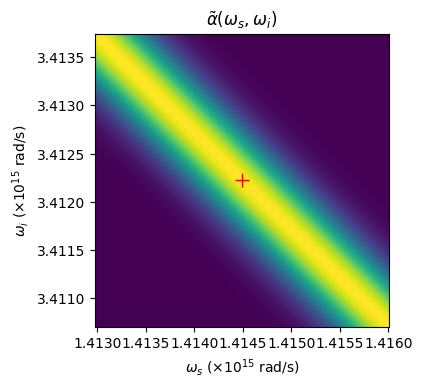

In [62]:
# === Parámetros físicos ===
Gamma = 0.193             # aproximación sinc -> gauss
L = 0.1            # longitud del medio [m] (ajusta: p.ej. 0.10 = 10 cm)

# --- Punto de operación (en µm) ya definido por ti ---
lambda_p_op, lambda_s_op, lambda_i_op = pts2[:,0][0], pts2[:,1][1], pts2[:,1][0]

#lambda_p_opm, lam_s_axism, lambda_i_opm = lambda_p_op*1e6

tau_s = L*(k_prime(lambda_p_op, p, dp) - k_prime(lambda_s_op, p, dp))           #s
tau_i = L*(k_prime(lambda_p_op, p, dp) - k_prime(lambda_i_op, p, dp))           #s

# Pasar a frecuencias angulares
omega_p = 2*np.pi*c / (lambda_p_op*1e-6)
omega_s0 = 2*np.pi*c / (lambda_s_op*1e-6)
omega_i0 = 2*np.pi*c / (lambda_i_op*1e-6)

# Comprobar centrado
delta_E = (omega_s0 + omega_i0) - 2*omega_p
print(f"2omp - (oms0+omi0) = {-delta_E:.3e} rad/s")

# === Condición de factorabilidad: 1/σ^2 = -(Γ L^2 / 4) τs τi ===
prod = tau_s * tau_i   # tau_s,tau_i en [s]
if prod >= 0:
    raise ValueError("No se puede factorar con σ real porque τs·τi ≥ 0 en este punto. Cambia geometría o punto.")
sigma_opt = np.sqrt(-2.0/(Gamma*prod))    # [rad/s]

print(f"σ_opt = {sigma_opt:.3e} rad/s")

# === Malla alrededor del punto de operación (elige el tamaño que prefieras) ===
# ancho en múltiplos de σ para visualizar
mul = 4.0
Ns = 2**10
omega_s_grid = np.linspace((omega_s0 - mul*sigma_opt), (omega_s0 + mul*sigma_opt), Ns)
omega_i_grid = np.linspace((omega_i0 - mul*sigma_opt), (omega_i0 + mul*sigma_opt), Ns)
omS, omI = np.meshgrid(omega_s_grid, omega_i_grid, indexing='xy')

# === Envolvente de bomba acoplada (anti-diagonal): α̃(oms,omi) ===
# forma estándar: depende de (oms + omi - 2omp)
alpha_tilde = np.exp(-((omS - omega_s0 + omI - omega_i0)**2)/(2*sigma_opt**2))

# (Opcional) gráfico rápido en λ para que se parezca a tu figura de referencia
lam_s_axis = (2*np.pi*c/omega_s_grid)*1e6  # µm
lam_i_axis = (2*np.pi*c/omega_i_grid)*1e6  # µm

# --- Escala para ejes en 10^15 rad/s ---
scl = 1e-15
oms_plot = omega_s_grid * scl
omi_plot = omega_i_grid * scl
oms0_plot = omega_s0 * scl
omi0_plot = omega_i0 * scl

plt.figure(figsize=(3.8,3.8))
plt.imshow(alpha_tilde,
           extent=[oms_plot.min(), oms_plot.max(), omi_plot.min(), omi_plot.max()],
           origin='lower', cmap='viridis', aspect='auto', vmin=0, vmax=1)
plt.plot([oms0_plot], [omi0_plot], 'r+', ms=10)

plt.xlabel(r'$\omega_s$ ($\times 10^{15}$ rad/s)')
plt.ylabel(r'$\omega_i$ ($\times 10^{15}$ rad/s)')
plt.title(r'$\tilde{\alpha}(\omega_s,\omega_i)$')
plt.show()

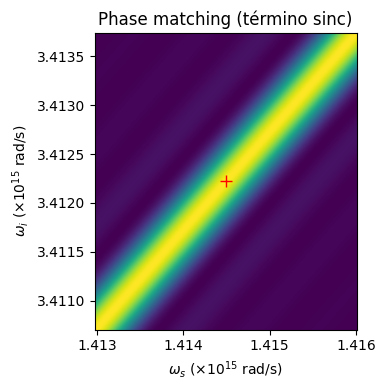

In [70]:
# --- Δk(oms, omi) y término de phase-matching (sinc) ---

Ldelk = tau_s*(omS - omega_s0) + tau_i*(omI - omega_i0)

x = Ldelk/2

# 3) sinc[(L/2)Δk] con L en µm; np.sinc(x) = sin(πx)/(πx)
PM = np.sinc(x/np.pi)*np.exp(1j*x)
PM2 = np.abs(PM)**2                   # (opcional) intensida

PM3 = PM2*alpha_tilde
# 5) Graficar en om (×10^15)
scl = 1e-15
oms_plot = omega_s_grid * scl
omi_plot = omega_i_grid * scl
oms0_plot, omi0_plot = omega_s0*scl, omega_i0*scl

plt.figure(figsize=(4.0,4.0))
im = plt.imshow(PM2, extent=[oms_plot.min(), oms_plot.max(),
                             omi_plot.min(), omi_plot.max()],
                origin='lower', cmap='viridis', aspect='auto',
                vmin=0, vmax=1)

plt.plot([oms0_plot], [omi0_plot], 'r+', ms=9)
plt.xlabel(r'$\omega_s$ ($\times 10^{15}$ rad/s)')
plt.ylabel(r'$\omega_i$ ($\times 10^{15}$ rad/s)')
plt.title('Phase matching (término sinc)')
plt.tight_layout()
plt.show()


In [ ]:
#Calculo de la JSA

omp = np.linspace(omega_p - mul*sigma_opt, omega_p - mul*sigma_opt, Ns)
omp2 = omS + omI - omp[:,None,None]

norm = 1.0/(sigma_opt*np.sqrt(2*np.pi))
alfa  = norm*np.exp(-0.5*((omp - omega_p)/sigma_opt)**2)[:,None,None]
alfap = norm*np.exp(-0.5*((omp2 - omega_p)/sigma_opt)**2)


def jsa_integral(omega_s_axis, omega_i_axis, omega_p, sigma_omega, p_neff):
    """
    Devuelve JSA (compleja) en una malla (oms, omi) evaluando la integral de convolución.
    - p_neff: polinomio (np.poly1d) de n_eff(λ) con λ en micras (µm)
    - L en metros, om en rad/s
    """
    # malla 2D de salida
    omS, omI = np.meshgrid(omega_s_axis, omega_i_axis, indexing='xy')

    # malla 1D de integración alrededor de omp
    om = np.linspace(omega_p - 6*sigma_omega, omega_p + 6*sigma_omega, 801)  # denso y simétrico
    dom = om[1]-om[0]
    omp2 = omS + omI - om[:,None,None]  # shape: (Nom, Ns, Ni)

    # alfa(om) y alfa(om') (gaussianas normalizadas en om)
    norm = 1.0/(sigma_omega*np.sqrt(2*np.pi))
    alfa  = norm*np.exp(-0.5*((om - omega_p)/sigma_omega)**2)[:,None,None]
    alfap = norm*np.exp(-0.5*((omp2 - omega_p)/sigma_omega)**2)

    # helper: k(om) via λ(om)=2πc/om en µm
    def k_of_omega(om):
        lam_um = (2*np.pi*c / om) * 1e6    # µm
        neff   = np.polyval(p_neff, lam_um)
        # k en 1/µm -> pásalo a 1/m multiplicando por 1e6 si tu k(λ) era (2π/λ[µm])*n
        return (2*np.pi/lam_um)*neff * 1e6

    kom   = k_of_omega(om)[:,None,None]
    komp2 = k_of_omega(omp2)
    koms  = k_of_omega(omS)
    komi  = k_of_omega(omI)

    Δk = kom + komp2 - koms[None,:,:] - komi[None,:,:]   # (Nom, Ns, Ni) en 1/m
    x  = 0.5*L*Δk                                     # adimensional

    PM = np.sinc(x/np.pi)*np.exp(1j*x)
    integrand = alfa * alfap * PM
    JSA = np.trapz(integrand, om, axis=0)             # (Ns, Ni) complejo

    return JSA
